# Nanoplasma: export reduced H5 + plots 

This notebook has two workflows:

1) **Export reduced HDF5** (radial/spectra/time series) using your working exporter module `ana_extract_v2.py`.
2) **(Optional) Append map slices** (|E| and particle density maps) into the same H5 from raw openPMD fields/particles.

Everything is written/read from your scratch path:
`/p/scratch/jureap18/medina2/2026_nanoplasma/Run001_reduced.h5`


In [21]:
# --- Imports ---
import os, glob
import numpy as np
import h5py, glob, adios2
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import scipy.constants as sc
from nanoplasma_analysis_final import extract_step_from_filename

# IMPORTANT:
# Use your working exporter (no indentation issues).
# Ensure ana_extract_v2.py is in the SAME folder as this notebook.
from ana_extract_v3 import NanoPlasmaRun


In [22]:
# --- User settings (EDIT HERE) ---\n",
#SIMOUTPUT = "/p/scratch/jureap18/medina2/2026_nanoplasma/001_OnceIonized/simOutput/"
#OUT_H5    = "/p/scratch/jureap18/medina2/2026_nanoplasma/Run001_reduced.h5"

#SIMOUTPUT = "/p/scratch/jureap18/medina2/2026_nanoplasma/003_Neutral_noAtomPhysics/simOutput/"
#OUT_H5    = "/p/scratch/jureap18/medina2/2026_nanoplasma/Run003_reduced.h5"

SIMOUTPUT = "/p/scratch/jureap18/medina2/2026_nanoplasma/004_Neutral_Smallsteps/simOutput/"
OUT_H5    = "/p/scratch/jureap18/medina2/2026_nanoplasma/Run004_reduced_log.h5"

LASER_PEAK_STEP = 89603
ION_SPECIES = "He_i"
E_SPECIES   = "He_e"
ZMAX = 2

# Binning\n",
R_MAX_NM = 500.0
N_R = 2000
MU_BINS = 720
E_MAX_EV = 2000.0
N_E = 1200
LOG_E = True

## 1) Export reduced HDF5 (radial/spectra/time series)

In [23]:
run = NanoPlasmaRun(path=SIMOUTPUT, laser_peak_at_target=LASER_PEAK_STEP)
out = run.export_reduced_h5(
    out_h5=OUT_H5,
    store_slices=True,
    slice_every=1,          # or your cadence
    slice_y_nm=300.0,       # same as your plotting convention
    electron_density_field="He_e_all_density",
    ion_charge_density_field="He_i_all_density",
    store_pxy=True,
    p_bins=256,             # VMI resolution
    log_energy=True,
    # p_max_e_SI=None,      # auto from E_max and mass
)
print("Wrote:", out)


/p/scratch/pwfa-trojan/medina2/conda_envs/picongpu/lib/python3.14/site-packages/numpy/_core/numeric.py:386: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


[export_reduced_h5] outputs: 57
[export_reduced_h5] r bins: 600 up to 2000.0 nm
[export_reduced_h5] mu bins: 360, energy bins: 800 up to 2000.0 eV
[export_reduced_h5] slices: on (57 stored)
[export] 1/57  step=0
[export] 2/57  step=20000
[export] 3/57  step=40000
[export] 4/57  step=42000
[export] 5/57  step=44000
[export] 6/57  step=46000
[export] 7/57  step=48000
[export] 8/57  step=50000
[export] 9/57  step=52000
[export] 10/57  step=54000
[export] 11/57  step=56000
[export] 12/57  step=58000
[export] 13/57  step=60000
[export] 14/57  step=62000
[export] 15/57  step=64000
[export] 16/57  step=66000
[export] 17/57  step=68000
[export] 18/57  step=70000
[export] 19/57  step=72000
[export] 20/57  step=74000
[export] 21/57  step=76000
[export] 22/57  step=78000
[export] 23/57  step=80000
[export] 24/57  step=82000
[export] 25/57  step=84000
[export] 26/57  step=86000
[export] 27/57  step=88000
[export] 28/57  step=90000
[export] 29/57  step=92000
[export] 30/57  step=94000
[export] 31/5

## 1b) Export Macrocells - reduced PIC position/momenta

**optional for better binning if necesary**

In [5]:

# --- settings ---
BLOCK = (8,8,8)        # macrocell block in PIC cells
STORE_EVERY = 1           # set to 5 or 10 if you want fewer timesteps
DTYPE = np.float32
COMPRESSION = "gzip"
COMP_LEVEL = 4

files = sorted(glob.glob(SIMOUTPUT + "/openPMD/*.bp5"))
if len(files) == 0:
    raise RuntimeError("No bp5 files found")

# Grid shape from first file (fields path!)
with adios2.Stream(files[0], "r") as f:
    step0 = extract_step_from_filename(files[0])
    for _ in f.steps():
        Nz, Ny, Nx = np.array(
            f.available_variables()[f"/data/{step0}/fields/B/x"]["Shape"].split(", "),
            dtype=int
        )
        break
print("Grid Nx,Ny,Nz =", Nx,Ny,Nz)

bx,by,bz = BLOCK
mx = (Nx + bx - 1)//bx
my = (Ny + by - 1)//by
mz = (Nz + bz - 1)//bz
nvox = mx*my*mz
print("Macro dims mx,my,mz =", mx,my,mz, "voxels =", nvox)

def lin(ix,iy,iz):
    return ix + mx*(iy + my*iz)

def bincount3(lidx, w, minlength):
    return np.bincount(lidx, weights=w, minlength=minlength)

with h5py.File(OUT_H5, "a") as h5:
    gm = h5.require_group("macrocell3d")
    gm.attrs["block_cells"] = np.array([bx,by,bz], dtype=np.int32)
    gm.attrs["macro_dims"] = np.array([mx,my,mz], dtype=np.int32)
    gm.attrs["grid_dims"]  = np.array([Nx,Ny,Nz], dtype=np.int32)
    gm.attrs["dtype"] = "float32"

    for k, fn in enumerate(files[::STORE_EVERY]):
        step = extract_step_from_filename(fn)
        print("macrocell step", step)

        with adios2.Stream(fn, "r") as f:
            for _ in f.steps():
                def read_part(f, step, sp):
                    """
                    Safe particle reader:
                    - returns empty arrays if the species/records are missing at this step
                    - avoids ADIOS2 ValueError for missing variables
                    """
                    # ask ADIOS2 what exists at this step
                    av = f.available_variables()
                
                    def read_or_empty(name, dtype=np.float64):
                        if name not in av:
                            return np.empty((0,), dtype=dtype)
                        return f.read(name).astype(dtype)
                
                    base = f"/data/{step}/particles/{sp}"
                    x  = read_or_empty(f"{base}/position/x", np.float64)
                    y  = read_or_empty(f"{base}/position/y", np.float64)
                    z  = read_or_empty(f"{base}/position/z", np.float64)
                    w  = read_or_empty(f"{base}/weighting",  np.float64)
                
                    # if no particles, bail early
                    if x.size == 0:
                        return x, y, z, w, np.empty((0,), np.float64), np.empty((0,), np.float64), np.empty((0,), np.float64)
                
                    px = read_or_empty(f"{base}/momentum/x", np.float64)
                    py = read_or_empty(f"{base}/momentum/y", np.float64)
                    pz = read_or_empty(f"{base}/momentum/z", np.float64)
                
                    return x, y, z, w, px, py, pz

                # electrons
                xe,ye,ze,we,pxe,pye,pze = read_part(f, step, E_SPECIES)
                mex = np.clip((np.floor(xe).astype(np.int64)//bx), 0, mx-1)
                mey = np.clip((np.floor(ye).astype(np.int64)//by), 0, my-1)
                mez = np.clip((np.floor(ze).astype(np.int64)//bz), 0, mz-1)
                le = lin(mex,mey,mez)

                # ions
                xi,yi,zi,wi,pxi,pyi,pzi = read_part(f, step,ION_SPECIES)
                mix = np.clip((np.floor(xi).astype(np.int64)//bx), 0, mx-1)
                miy = np.clip((np.floor(yi).astype(np.int64)//by), 0, my-1)
                miz = np.clip((np.floor(zi).astype(np.int64)//bz), 0, mz-1)
                li = lin(mix,miy,miz)

                # ion charge state Z from boundElectrons (if exists)
                try:
                    be = f.read(f"/data/{step}/particles/{ION_SPECIES}/boundElectrons").astype(np.int32)
                    wZ = f.read(f"/data/{step}/particles/{ION_SPECIES}/weighting").astype(np.float64)
                    Z = np.clip(ZMAX - be, 0, ZMAX).astype(np.float64)
                    qi = sc.e * Z * wZ
                except Exception:
                    qi = sc.e * wi  # fallback +1

                # charges
                qe = -sc.e * we

                # accumulate (1D), then reshape to (mz,my,mx) (z,y,x)
                qe_sum = bincount3(le, qe, nvox).reshape(mz,my,mx)
                qi_sum = bincount3(li, qi, nvox).reshape(mz,my,mx)

                Pex = bincount3(le, pxe*we, nvox).reshape(mz,my,mx)
                Pey = bincount3(le, pye*we, nvox).reshape(mz,my,mx)
                Pez = bincount3(le, pze*we, nvox).reshape(mz,my,mx)

                Pix = bincount3(li, pxi*wi, nvox).reshape(mz,my,mx)
                Piy = bincount3(li, pyi*wi, nvox).reshape(mz,my,mx)
                Piz = bincount3(li, pzi*wi, nvox).reshape(mz,my,mx)

                g = gm.require_group(f"step_{step:08d}")
                # overwrite if rerun
                for name in ["q_e_C","q_i_C","P_e_x","P_e_y","P_e_z","P_i_x","P_i_y","P_i_z"]:
                    if name in g: del g[name]

                g.create_dataset("q_e_C", data=qe_sum.astype(DTYPE), compression=COMPRESSION, compression_opts=COMP_LEVEL, chunks=True)
                g.create_dataset("q_i_C", data=qi_sum.astype(DTYPE), compression=COMPRESSION, compression_opts=COMP_LEVEL, chunks=True)
                g.create_dataset("P_e_x", data=Pex.astype(DTYPE),  compression=COMPRESSION, compression_opts=COMP_LEVEL, chunks=True)
                g.create_dataset("P_e_y", data=Pey.astype(DTYPE),  compression=COMPRESSION, compression_opts=COMP_LEVEL, chunks=True)
                g.create_dataset("P_e_z", data=Pez.astype(DTYPE),  compression=COMPRESSION, compression_opts=COMP_LEVEL, chunks=True)
                g.create_dataset("P_i_x", data=Pix.astype(DTYPE),  compression=COMPRESSION, compression_opts=COMP_LEVEL, chunks=True)
                g.create_dataset("P_i_y", data=Piy.astype(DTYPE),  compression=COMPRESSION, compression_opts=COMP_LEVEL, chunks=True)
                g.create_dataset("P_i_z", data=Piz.astype(DTYPE),  compression=COMPRESSION, compression_opts=COMP_LEVEL, chunks=True)

                break

print("Done. Appended macrocell3d into:", OUT_H5)

Grid Nx,Ny,Nz = 1024 1600 1024
Macro dims mx,my,mz = 128 200 128 voxels = 3276800
macrocell step 0
macrocell step 10000
macrocell step 100000



KeyboardInterrupt



## 2) Load reduced HDF5

In [18]:
h5 = h5py.File(OUT_H5, "r")

t_fs = h5["axes/time_fs"][:]
r_edges_nm = h5["axes/r_edges_m"][:] * 1e9
r_mid_nm   = h5["axes/r_mid_m"][:]   * 1e9

E_mid = h5["axes/E_mid_eV"][:]
mu_mid = h5["axes/mu_mid"][:]

ts = h5["timeseries"]
spec = h5["spectra"]
rad = h5["radial"]

print("Loaded:", OUT_H5)
print("Nt =", len(t_fs))

with h5py.File(h5,"r") as f:
    for k in f.keys():
        print(k, "->", list(f[k].keys())[:20])

Loaded: /p/scratch/jureap18/medina2/2026_nanoplasma/Run001_reduced.h5V2.h5
Nt = 21


TypeError: expected str, bytes or os.PathLike object, not File

## Plot 1: Ion charge fractions + energies + ⟨Z⟩

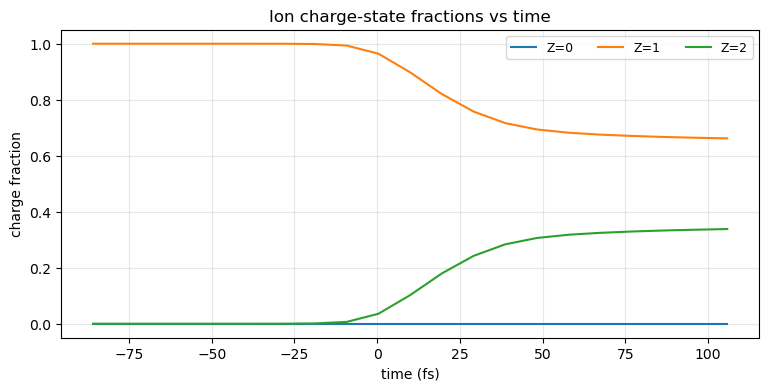

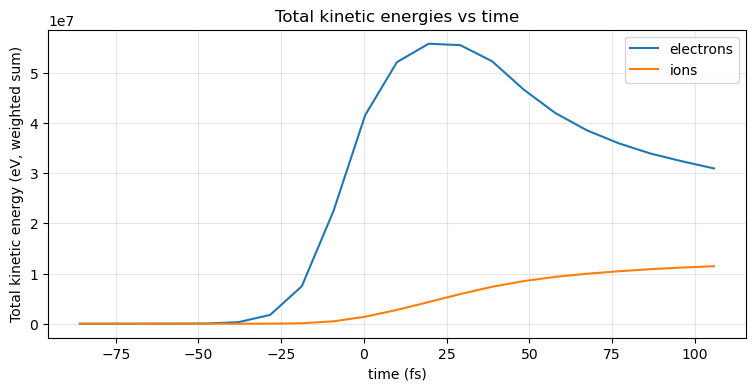

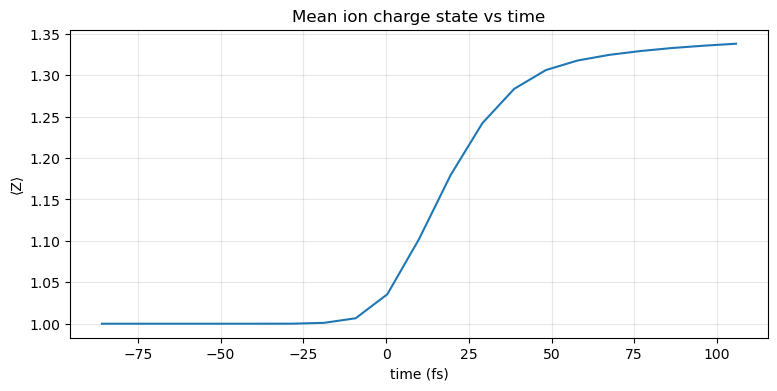

In [19]:
charge_frac = ts[f"{ION_SPECIES}_charge_frac"][:]
Z_mean = ts[f"{ION_SPECIES}_Z_mean"][:]

Ekin_e = ts[f"{E_SPECIES}_Ekin_total_eV"][:]
Ekin_i = ts[f"{ION_SPECIES}_Ekin_total_eV"][:]

fig, ax = plt.subplots(figsize=(9,4))
for Z in range(charge_frac.shape[1]):
    ax.plot(t_fs, charge_frac[:,Z], label=f"Z={Z}")
ax.set_xlabel("time (fs)")
ax.set_ylabel("charge fraction")
ax.set_title("Ion charge-state fractions vs time")
ax.legend(ncol=3, fontsize=9)
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(t_fs, Ekin_e, label="electrons")
ax.plot(t_fs, Ekin_i, label="ions")
ax.set_xlabel("time (fs)")
ax.set_ylabel("Total kinetic energy (eV, weighted sum)")
ax.set_title("Total kinetic energies vs time")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(t_fs, Z_mean)
ax.set_xlabel("time (fs)")
ax.set_ylabel("⟨Z⟩")
ax.set_title("Mean ion charge state vs time")
ax.grid(True, alpha=0.3)
plt.show()


## Plot 2: Electron energy spectra

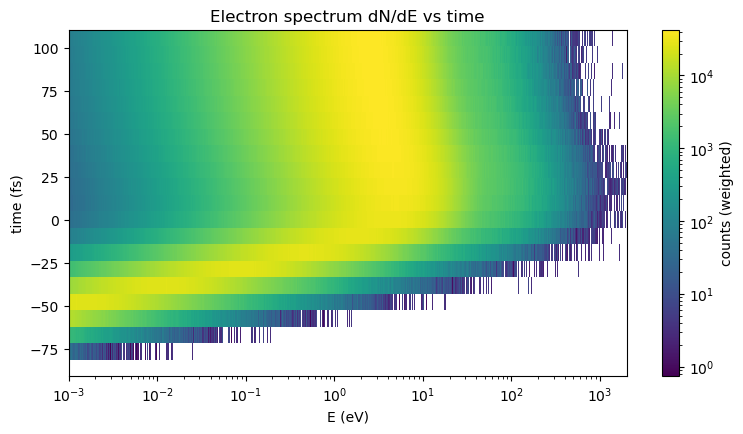

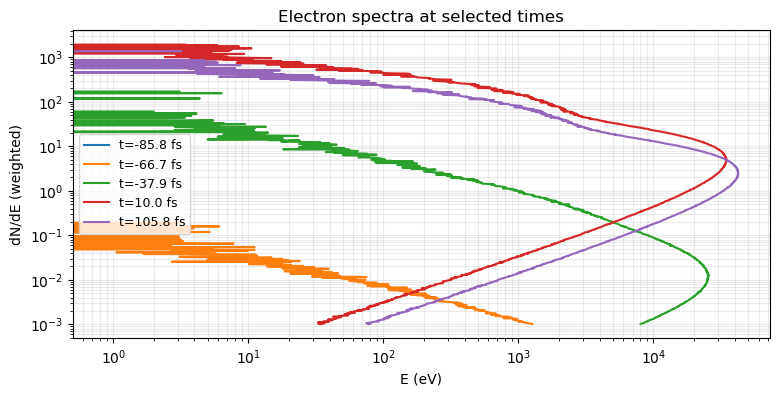

In [24]:
dNdE_e = spec[f"{E_SPECIES}_dNdE"][:]   # (Nt, NE)

fig, ax = plt.subplots(figsize=(9,4.5))
H = np.where(dNdE_e>0, dNdE_e, np.nan)
im = ax.pcolormesh(E_mid, t_fs, H, norm=LogNorm(), shading="auto")
ax.set_xscale("log" if LOG_E else "linear")
ax.set_xlabel("E (eV)")
ax.set_ylabel("time (fs)")
ax.set_title("Electron spectrum dN/dE vs time")
fig.colorbar(im, ax=ax, label="counts (weighted)")
plt.show()

sel = [0, len(t_fs)//8,len(t_fs)//4, len(t_fs)//2, -1]
fig, ax = plt.subplots(figsize=(9,4))
for idx in sel:
    ax.plot(dNdE_e[idx],E_mid, label=f"t={t_fs[idx]:.1f} fs")
ax.set_xscale("log" if LOG_E else "linear")
ax.set_yscale("log")
ax.set_xlabel("E (eV)")
ax.set_ylabel("dN/dE (weighted)")
ax.set_title("Electron spectra at selected times")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.25)
plt.show()


## Plot 3: Angular distribution vs time + asymmetry

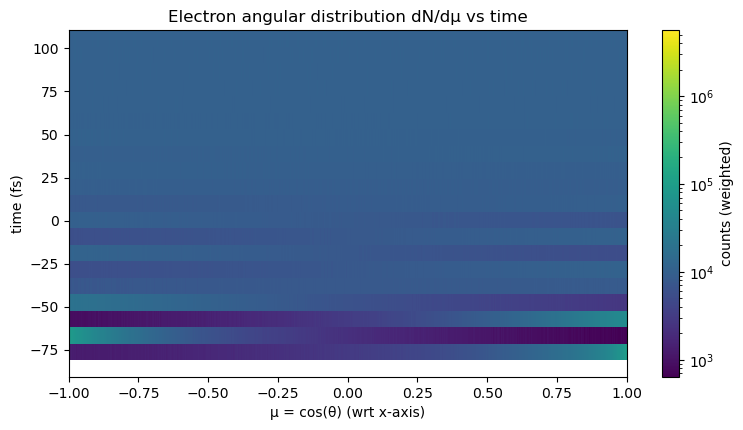

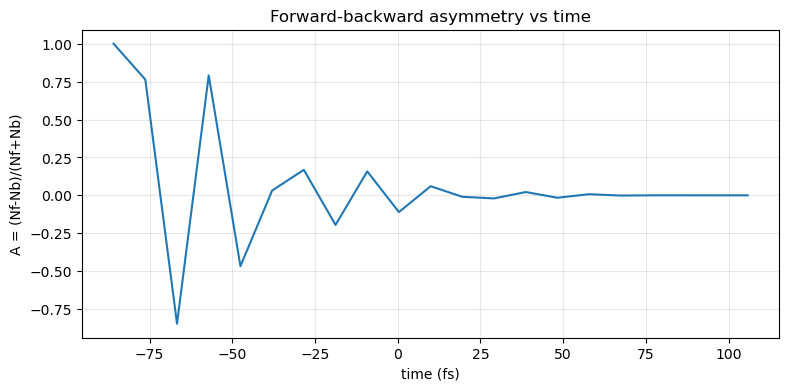

In [23]:
dNdmu = spec[f"{E_SPECIES}_dNdmu"][:]  # (Nt, Nmu)

fig, ax = plt.subplots(figsize=(9,4.5))
H = np.where(dNdmu>0, dNdmu, np.nan)
im = ax.pcolormesh(mu_mid, t_fs, H, norm=LogNorm(), shading="auto")
ax.set_xlabel("μ = cos(θ) (wrt x-axis)")
ax.set_ylabel("time (fs)")
ax.set_title("Electron angular distribution dN/dμ vs time")
fig.colorbar(im, ax=ax, label="counts (weighted)")
plt.show()

mu = mu_mid
forward = mu > 0
backward = mu < 0
Nf = np.nansum(dNdmu[:, forward], axis=1)
Nb = np.nansum(dNdmu[:, backward], axis=1)
A = (Nf - Nb) / (Nf + Nb + 1e-30)

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(t_fs, A)
ax.set_xlabel("time (fs)")
ax.set_ylabel("A = (Nf-Nb)/(Nf+Nb)")
ax.set_title("Forward-backward asymmetry vs time")
ax.grid(True, alpha=0.3)
plt.show()


## Plot 4: Radial kymographs + expansion radii

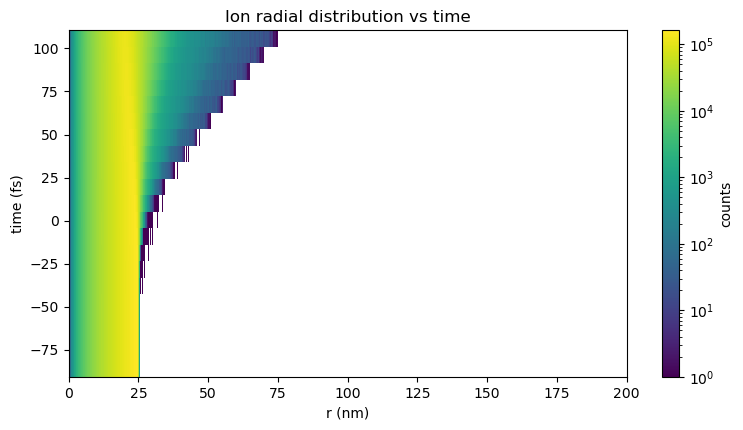

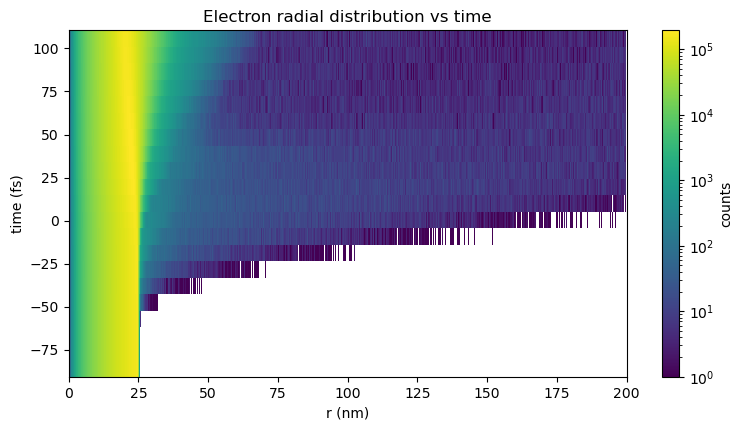

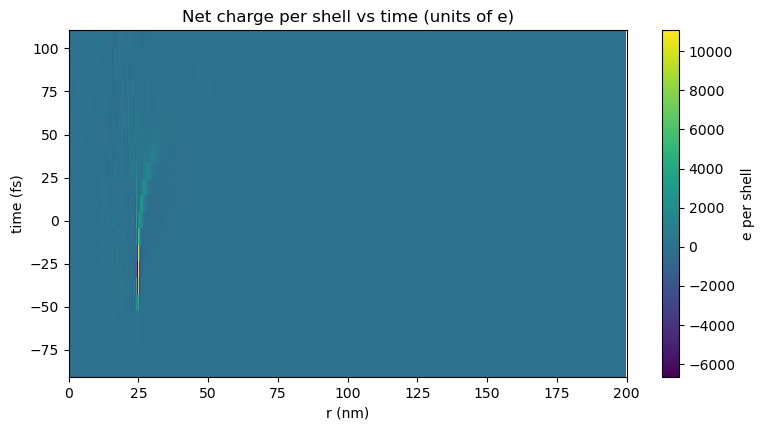

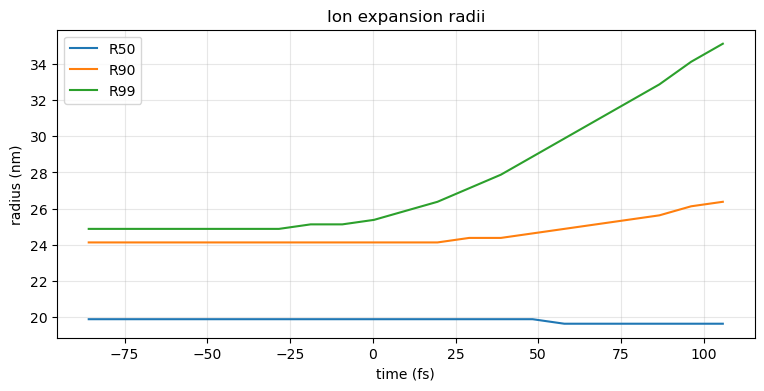

In [24]:
n_i = rad[f"{ION_SPECIES}_n_r"][:]
n_e = rad[f"{E_SPECIES}_n_r"][:]
rho_net_shell_C = rad["rho_net_shell_C"][:]

t = t_fs
dt = np.median(np.diff(t)) if len(t)>1 else 1.0
t_edges = np.concatenate(([t[0]-0.5*dt], 0.5*(t[1:]+t[:-1]), [t[-1]+0.5*dt]))

R_VIEW_NM = 200.0
ncols = int(np.searchsorted(r_edges_nm, R_VIEW_NM, side="right")) - 1
ncols = max(1, min(ncols, n_i.shape[1]))

fig, ax = plt.subplots(figsize=(9,4.5))
im = ax.pcolormesh(r_edges_nm[:ncols+1], t_edges, n_i[:, :ncols],
                   norm=LogNorm(vmin=1, vmax=np.nanmax(n_i)), shading="flat")
ax.set_xlim(0, R_VIEW_NM)
ax.set_xlabel("r (nm)"); ax.set_ylabel("time (fs)")
ax.set_title("Ion radial distribution vs time")
fig.colorbar(im, ax=ax, label="counts")
plt.show()

fig, ax = plt.subplots(figsize=(9,4.5))
im = ax.pcolormesh(r_edges_nm[:ncols+1], t_edges, n_e[:, :ncols],
                   norm=LogNorm(vmin=1, vmax=np.nanmax(n_e)), shading="flat")
ax.set_xlim(0, R_VIEW_NM)
ax.set_xlabel("r (nm)"); ax.set_ylabel("time (fs)")
ax.set_title("Electron radial distribution vs time")
fig.colorbar(im, ax=ax, label="counts")
plt.show()

net_charge_e = rho_net_shell_C / sc.e
fig, ax = plt.subplots(figsize=(9,4.5))
im = ax.pcolormesh(r_edges_nm[:ncols+1], t_edges, net_charge_e[:, :ncols], shading="flat")
ax.set_xlim(0, R_VIEW_NM)
ax.set_xlabel("r (nm)"); ax.set_ylabel("time (fs)")
ax.set_title("Net charge per shell vs time (units of e)")
fig.colorbar(im, ax=ax, label="e per shell")
plt.show()

cum = np.cumsum(n_i, axis=1)
tot = cum[:, -1] + 1e-30
cdf = cum / tot[:, None]

def percentile_radius_nm(p):
    idx = np.argmax(cdf >= p, axis=1)
    idx = np.clip(idx, 0, len(r_mid_nm)-1)
    return r_mid_nm[idx]

R50 = percentile_radius_nm(0.5)
R90 = percentile_radius_nm(0.9)
R99 = percentile_radius_nm(0.99)

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(t, R50, label="R50")
ax.plot(t, R90, label="R90")
ax.plot(t, R99, label="R99")
ax.set_xlabel("time (fs)")
ax.set_ylabel("radius (nm)")
ax.set_title("Ion expansion radii")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## Plot 5: Charge-state vs radius + ⟨Z⟩(r,t)

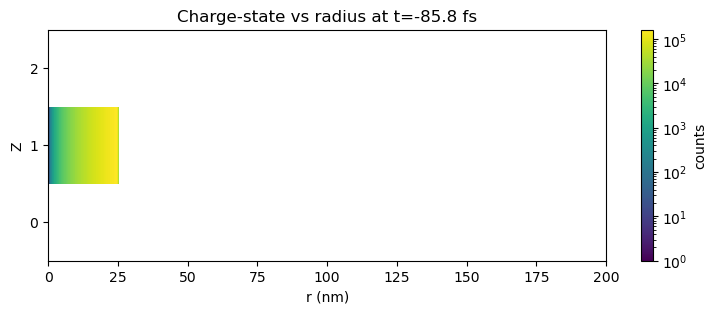

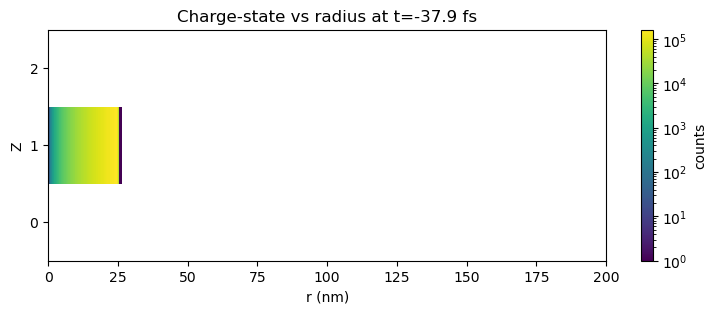

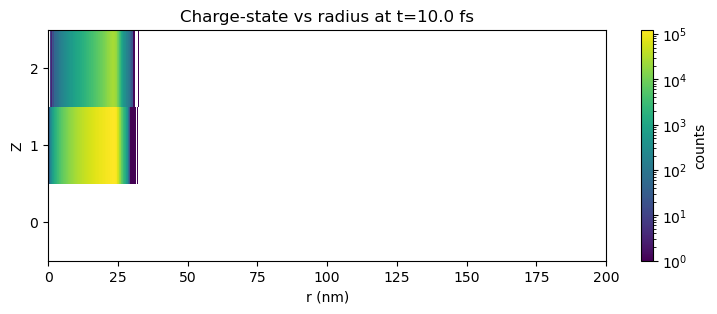

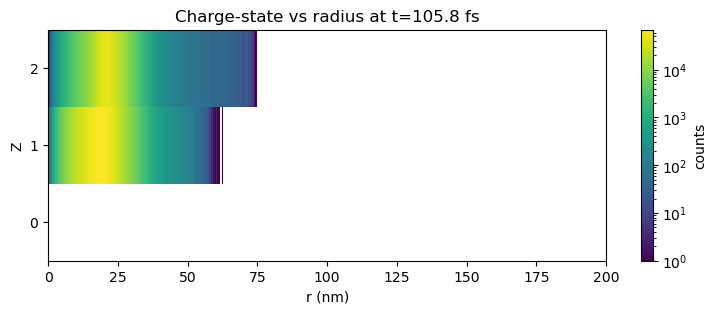

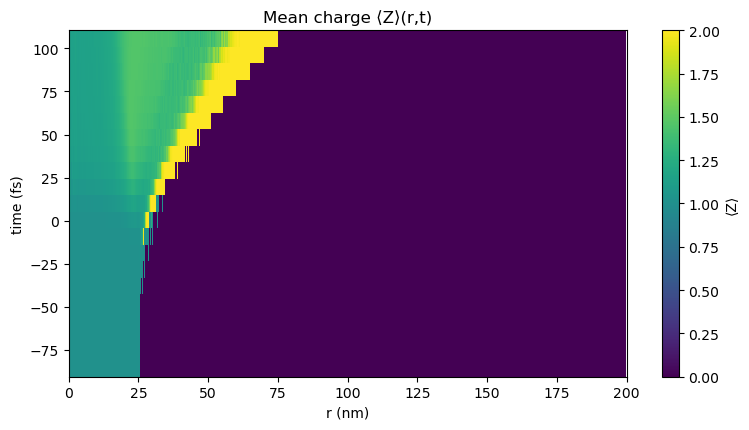

In [25]:
charge_rZ = rad[f"{ION_SPECIES}_charge_rZ_counts"][:]
Z_values = rad["Z_values"][:]
Zmax_here = int(Z_values.max())
Z_edges = np.arange(-0.5, Zmax_here + 1.5, 1.0)

R_VIEW_NM = 200.0
ncols = int(np.searchsorted(r_edges_nm, R_VIEW_NM, side="right")) - 1
ncols = max(1, min(ncols, charge_rZ.shape[1]))

sel = [0, len(t_fs)//4, len(t_fs)//2, len(t_fs)-1]
for idx in sel:
    H = charge_rZ[idx, :ncols, :].T
    vmax = np.nanmax(H)
    if vmax <= 0:
        continue
    fig, ax = plt.subplots(figsize=(9,3))
    im = ax.pcolormesh(r_edges_nm[:ncols+1], Z_edges, H,
                       norm=LogNorm(vmin=1, vmax=vmax), shading="flat")
    ax.set_xlim(0, R_VIEW_NM)
    ax.set_xlabel("r (nm)")
    ax.set_ylabel("Z")
    ax.set_yticks(Z_values)
    ax.set_title(f"Charge-state vs radius at t={t_fs[idx]:.1f} fs")
    fig.colorbar(im, ax=ax, label="counts")
    plt.show()

num = np.tensordot(charge_rZ, Z_values, axes=([2],[0]))
den = np.sum(charge_rZ, axis=2) + 1e-30
Zmean_rt = num / den

t = t_fs
dt = np.median(np.diff(t)) if len(t)>1 else 1.0
t_edges = np.concatenate(([t[0]-0.5*dt], 0.5*(t[1:]+t[:-1]), [t[-1]+0.5*dt]))

fig, ax = plt.subplots(figsize=(9,4.5))
im = ax.pcolormesh(r_edges_nm[:ncols+1], t_edges, Zmean_rt[:, :ncols], shading="flat")
ax.set_xlim(0, R_VIEW_NM)
ax.set_xlabel("r (nm)")
ax.set_ylabel("time (fs)")
ax.set_title("Mean charge ⟨Z⟩(r,t)")
fig.colorbar(im, ax=ax, label="⟨Z⟩")
plt.show()


## Plot 6: Creation rates (how fast charge/electrons are created)

<>:43: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:43: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_536144/142448160.py:43: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax.set_title("Ionization rate: $d\langle Z\rangle/dt$")


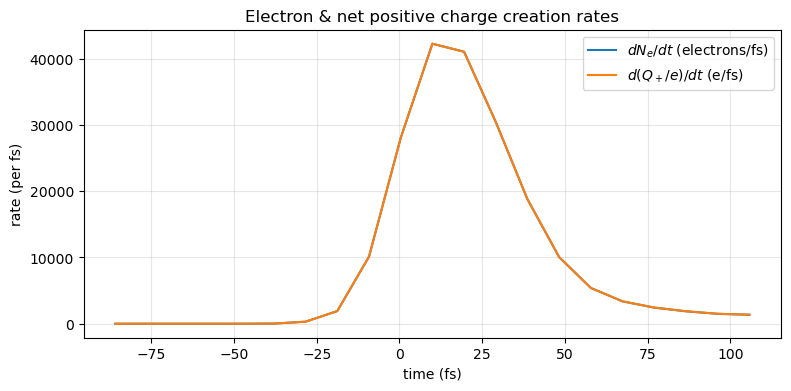

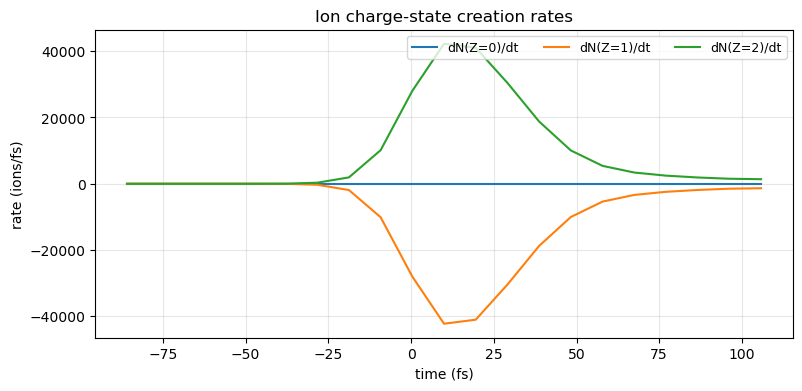

ValueError: 
Ionization rate: $d\langle Zangle/dt$
                 ^
ParseException: Expected end of text, found '$'  (at char 17), (line:1, col:18)

<Figure size 900x400 with 1 Axes>

In [26]:
t = h5["axes/time_fs"][:]
Ne = ts[f"{E_SPECIES}_N_real"][:]
Ni = ts[f"{ION_SPECIES}_N_real"][:]
charge_frac = ts[f"{ION_SPECIES}_charge_frac"][:]
Zmean = ts[f"{ION_SPECIES}_Z_mean"][:]
Zvals = np.arange(charge_frac.shape[1], dtype=float)

def d_dt(y, t):
    return np.gradient(y, t, axis=0)

dNe_dt = d_dt(Ne, t)
N_Z = Ni[:, None] * charge_frac
dN_Z_dt = d_dt(N_Z, t)

Qplus_over_e = np.sum(Zvals[None, :] * N_Z, axis=1)
dQplus_dt_over_e = d_dt(Qplus_over_e, t)
dZmean_dt = d_dt(Zmean, t)

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(t, dNe_dt, label=r"$dN_e/dt$ (electrons/fs)")
ax.plot(t, dQplus_dt_over_e, label=r"$d(Q_+/e)/dt$ (e/fs)")
ax.set_xlabel("time (fs)")
ax.set_ylabel("rate (per fs)")
ax.set_title("Electron & net positive charge creation rates")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(9,4))
for Z in range(N_Z.shape[1]):
    ax.plot(t, dN_Z_dt[:, Z], label=f"dN(Z={Z})/dt")
ax.set_xlabel("time (fs)")
ax.set_ylabel("rate (ions/fs)")
ax.set_title("Ion charge-state creation rates")
ax.grid(True, alpha=0.3)
ax.legend(ncol=3, fontsize=9)
plt.show()

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(t, dZmean_dt)
ax.set_xlabel("time (fs)")
ax.set_ylabel(r"$d\langle Z\rangle/dt$ (per fs)")
ax.set_title("Ionization rate: $d\langle Z\rangle/dt$")
ax.grid(True, alpha=0.3)
plt.show()


## 3) Optional: append map slices (|E| and particle density maps)

Turn `DO_APPEND_SLICES=True` if you want to keep maps inside the reduced H5, then you can delete raw openPMD safely.


In [27]:
import h5py
OUT_H5 = "/p/scratch/jureap18/medina2/2026_nanoplasma/Run001_reduced.h5"
with h5py.File(OUT_H5, "r") as h:
    print("has /slices ?", "slices" in h)
    if "slices" in h:
        print("example slice keys:", list(h["slices"].keys())[:3])
    print("has /macrocell3d ?", "macrocell3d" in h)

has /slices ? False
has /macrocell3d ? True


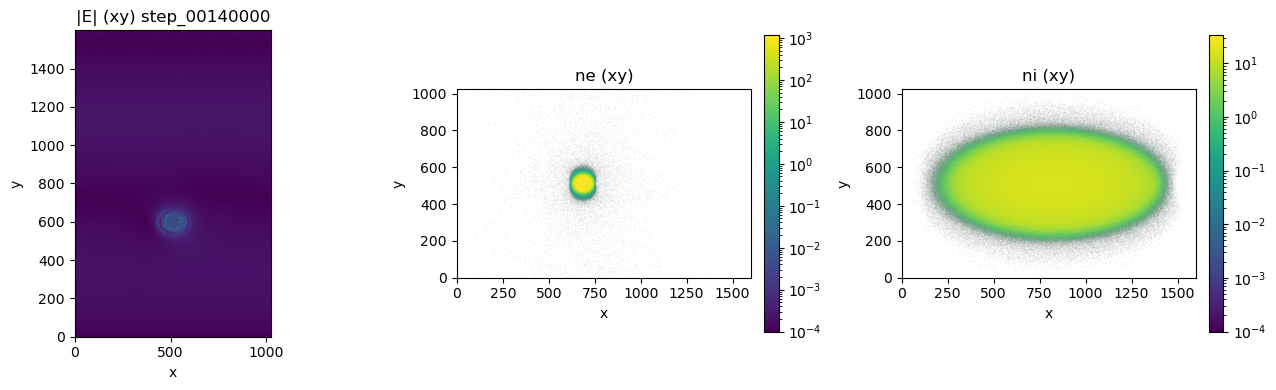

In [37]:
import h5py, numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

OUT_H5 = "/p/scratch/jureap18/medina2/2026_nanoplasma/Run001_reduced.h5"

STEP = 140000# set to an int like 90000, or leave None to pick the first available

with h5py.File(OUT_H5, "r") as h:
    s = h["slices"]
    steps = sorted([k for k in s.keys() if k.startswith("step_")])
    if STEP is None:
        step_key = steps[0]
    else:
        step_key = f"step_{STEP:08d}"
    g = s[step_key]

    # field slice (if stored)
    E = g.get("Eabs_xy", None)
    ne = g.get("ne_xy", None)
    ni = g.get("ni_xy", None)

    fig, axs = plt.subplots(1, 3, figsize=(13,4))

    if E is not None:
        axs[0].imshow(E[...], origin="lower")
        axs[0].set_title(f"|E| (xy) {step_key}")
    else:
        axs[0].text(0.5,0.5,"No Eabs_xy in H5", ha="center", va="center")
    axs[0].set_xlabel("x"); axs[0].set_ylabel("y")

    if ne is not None:
        im = axs[1].imshow(np.where(ne[...]>0, ne[...], np.nan), origin="lower", norm=LogNorm())
        axs[1].set_title("ne (xy)")
        fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)
    else:
        axs[1].text(0.5,0.5,"No ne_xy in H5", ha="center", va="center")
    axs[1].set_xlabel("x"); axs[1].set_ylabel("y")

    if ni is not None:
        im = axs[2].imshow(np.where(ni[...]>0, ni[...], np.nan), origin="lower", norm=LogNorm())
        axs[2].set_title("ni (xy)")
        fig.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04)
    else:
        axs[2].text(0.5,0.5,"No ni_xy in H5", ha="center", va="center")
    axs[2].set_xlabel("x"); axs[2].set_ylabel("y")

    plt.tight_layout()
    plt.show()

## Optional: append 2D map slices into the reduced H5 (`/slices/...`)

Run this **once** (after exporting `OUT_H5`) if you want to reproduce the *field / electron / ion maps* later **without** keeping the raw openPMD output.

It will create:
- `/slices/step_XXXXXXXX/Eabs_xy`, `Eabs_xz`, `Eabs_yz` (if fields exist)
- `/slices/step_XXXXXXXX/ne_xy`, `ni_xy` (and xz/yz if enabled)

**Important:** Close any open read-only handle to `OUT_H5` before running (or restart kernel), otherwise HDF5 will refuse append mode.


In [29]:
# --- Append slices into OUT_H5 ---
# Set True to execute.
DO_APPEND_SLICES = True

# Choose what to store
STORE_FIELDS = True       # |E| from /data/<step>/fields/E/*
STORE_PARTICLE_MAPS = True
STORE_XZ_YZ = True        # if False, only xy slices are stored

import numpy as np, h5py, glob, adios2
from nanoplasma_analysis_final import extract_step_from_filename

# Make sure OUT_H5 isn't already open read-only in a variable named 'h5'
try:
    h5.close()
except Exception:
    pass

if DO_APPEND_SLICES:
    files = sorted(glob.glob(SIMOUTPUT + "/openPMD/*.bp5"))
    if len(files) == 0:
        raise RuntimeError("No bp5 files found under SIMOUTPUT/openPMD")

    # grid shape from first file (fields path)
    with adios2.Stream(files[0], "r") as f:
        step0 = extract_step_from_filename(files[0])
        for _ in f.steps():
            Nz, Ny, Nx = np.array(
                f.available_variables()[f"/data/{step0}/fields/B/x"]["Shape"].split(", "),
                dtype=int
            )
            break
    print("Grid Nx,Ny,Nz =", Nx, Ny, Nz)

    with h5py.File(OUT_H5, "a") as hf:
        gs = hf.require_group("slices")
        gs.attrs["Nx"] = int(Nx); gs.attrs["Ny"] = int(Ny); gs.attrs["Nz"] = int(Nz)

        def read_part(f, step, sp):
            x = f.read(f"/data/{step}/particles/{sp}/position/x").astype(np.float64)
            y = f.read(f"/data/{step}/particles/{sp}/position/y").astype(np.float64)
            z = f.read(f"/data/{step}/particles/{sp}/position/z").astype(np.float64)
            xo = f.read(f"/data/{step}/particles/{sp}/positionOffset/x").astype(np.int64)
            yo = f.read(f"/data/{step}/particles/{sp}/positionOffset/y").astype(np.int64)
            zo = f.read(f"/data/{step}/particles/{sp}/positionOffset/z").astype(np.int64)
            w  = f.read(f"/data/{step}/particles/{sp}/weighting").astype(np.float64)
            return (xo + x), (yo + y), (zo + z), w  # in cell units

        def hist2d(xc, yc, w, nx, ny):
            H, _, _ = np.histogram2d(xc, yc, bins=[nx, ny], weights=w)
            return H

        for fn in files:
            step = extract_step_from_filename(fn)
            print("Appending slices for step", step)

            with adios2.Stream(fn, "r") as f:
                for _ in f.steps():
                    # Field |E|
                    Eabs = None
                    if STORE_FIELDS:
                        try:
                            Ex = f.read(f"/data/{step}/fields/E/x")
                            Ey = f.read(f"/data/{step}/fields/E/y")
                            Ez = f.read(f"/data/{step}/fields/E/z")
                            Eabs = np.sqrt(Ex*Ex + Ey*Ey + Ez*Ez)   # (Nz,Ny,Nx)
                        except Exception:
                            Eabs = None

                    # Particles
                    xi, yi, zi, wi = read_part(f, step, ION_SPECIES)
                    xe, ye, ze, we = read_part(f, step, E_SPECIES)

                    # center via ion COM (cell units)
                    W = np.sum(wi) + 1e-30
                    x0 = float(np.sum(xi*wi)/W); y0 = float(np.sum(yi*wi)/W); z0 = float(np.sum(zi*wi)/W)
                    ix0 = int(np.clip(np.floor(x0), 0, Nx-1))
                    iy0 = int(np.clip(np.floor(y0), 0, Ny-1))
                    iz0 = int(np.clip(np.floor(z0), 0, Nz-1))

                    g = gs.require_group(f"step_{step:08d}")
                    g.attrs["center_cell"] = np.array([x0,y0,z0], dtype=np.float64)

                    # overwrite if rerun
                    for name in list(g.keys()):
                        if name.startswith(("Eabs_", "ne_", "ni_")):
                            del g[name]

                    # field slices
                    if Eabs is not None:
                        g.create_dataset("Eabs_xy", data=Eabs[iz0,:,:].astype(np.float32), compression="gzip", compression_opts=4)
                        if STORE_XZ_YZ:
                            g.create_dataset("Eabs_xz", data=Eabs[:,iy0,:].astype(np.float32), compression="gzip", compression_opts=4)
                            g.create_dataset("Eabs_yz", data=Eabs[:,:,ix0].astype(np.float32), compression="gzip", compression_opts=4)

                    # particle maps (full-grid histogram)
                    if STORE_PARTICLE_MAPS:
                        ni_xy = hist2d(xi, yi, wi, Nx, Ny)
                        ne_xy = hist2d(xe, ye, we, Nx, Ny)
                        g.create_dataset("ni_xy", data=ni_xy.astype(np.float32), compression="gzip", compression_opts=4)
                        g.create_dataset("ne_xy", data=ne_xy.astype(np.float32), compression="gzip", compression_opts=4)

                        if STORE_XZ_YZ:
                            ni_xz = hist2d(xi, zi, wi, Nx, Nz)
                            ne_xz = hist2d(xe, ze, we, Nx, Nz)
                            ni_yz = hist2d(yi, zi, wi, Ny, Nz)
                            ne_yz = hist2d(ye, ze, we, Ny, Nz)
                            g.create_dataset("ni_xz", data=ni_xz.astype(np.float32), compression="gzip", compression_opts=4)
                            g.create_dataset("ne_xz", data=ne_xz.astype(np.float32), compression="gzip", compression_opts=4)
                            g.create_dataset("ni_yz", data=ni_yz.astype(np.float32), compression="gzip", compression_opts=4)
                            g.create_dataset("ne_yz", data=ne_yz.astype(np.float32), compression="gzip", compression_opts=4)

                    break

    print("Done. /slices appended into:", OUT_H5)


Grid Nx,Ny,Nz = 1024 1600 1024
Appending slices for step 0
Appending slices for step 10000
Appending slices for step 100000
Appending slices for step 110000
Appending slices for step 120000
Appending slices for step 130000
Appending slices for step 140000
Appending slices for step 150000
Appending slices for step 160000
Appending slices for step 170000
Appending slices for step 180000
Appending slices for step 190000
Appending slices for step 20000
Appending slices for step 200000
Appending slices for step 30000
Appending slices for step 40000
Appending slices for step 50000
Appending slices for step 60000
Appending slices for step 70000
Appending slices for step 80000
Appending slices for step 90000
Done. /slices appended into: /p/scratch/jureap18/medina2/2026_nanoplasma/Run001_reduced.h5


## Close H5

In [6]:
h5.close()
print("Closed:", OUT_H5)


Closed: /p/scratch/jureap18/medina2/2026_nanoplasma/Run001_reduced.h5
